# Desafio Técnico — Engenharia de Dados

Resolução dos quatro desafios SQL do teste, sobre a base de um marketplace B2B de
alimentos (80 mil pedidos, 214 mil itens de pedido).

Stack: `pandas` + `pandasql` (SQLite rodando por cima dos DataFrames), seguindo o
notebook modelo que veio com o enunciado.

Antes de partir para as queries, fiz uma auditoria da base. Alguns problemas que
apareceram ali mudam a forma correta de escrever praticamente todas as respostas —
então essa parte vem primeiro.

In [1]:
# No Google Colab, descomente a linha abaixo:
# !pip install -q pandasql

In [2]:
import warnings
from pathlib import Path

import pandas as pd
from pandasql import sqldf

warnings.filterwarnings('ignore')

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda v: f'{v:,.2f}')

# executa SQL sobre os DataFrames do escopo global
pysqldf = lambda q: sqldf(q, globals())

In [3]:
# Procura os CSVs nos lugares mais prováveis (local ou Colab), para não precisar
# ajustar caminho na mão.
CANDIDATOS = [Path('dados'), Path('../dados'), Path('/content'), Path('/content/dados')]
DADOS = next((p for p in CANDIDATOS if (p / 'orders.csv').exists()), None)

if DADOS is None:
    raise FileNotFoundError(
        'CSVs não encontrados. Ajuste a lista CANDIDATOS ou suba os arquivos para '
        '/content no Colab.'
    )

buyers      = pd.read_csv(DADOS / 'buyers.csv')
order_items = pd.read_csv(DADOS / 'order_items.csv')
orders      = pd.read_csv(DADOS / 'orders.csv')
payments    = pd.read_csv(DADOS / 'payments.csv')
products    = pd.read_csv(DADOS / 'products.csv')
sellers     = pd.read_csv(DADOS / 'sellers.csv')

print(f'Dados carregados de: {DADOS.resolve()}\n')
for nome, df in [('buyers', buyers), ('order_items', order_items), ('orders', orders),
                 ('payments', payments), ('products', products), ('sellers', sellers)]:
    print(f'{nome:<12} {len(df):>7,} linhas  |  colunas: {list(df.columns)}')

Dados carregados de: /mnt/d/Users/renat/Downloads/Teste Engenheiro de Dados (1)/Teste Engenheiro de Dados/dados

buyers         3,001 linhas  |  colunas: ['id', 'name', 'city', 'state', 'segment', 'created_at']
order_items  214,768 linhas  |  colunas: ['id', 'order_id', 'product_id', 'qty', 'unit_price', 'discount']
orders        80,002 linhas  |  colunas: ['id', 'seller_id', 'buyer_id', 'status', 'created_at', 'total_value']
payments      80,000 linhas  |  colunas: ['id', 'order_id', 'paid_at', 'amount', 'method', 'status']
products         800 linhas  |  colunas: ['id', 'name', 'category', 'seller_id', 'active', 'unit_cost']
sellers          120 linhas  |  colunas: ['id', 'name', 'state', 'plan', 'created_at']


## Antes dos desafios: auditoria da base

O enunciado já avisa que os relatórios da empresa não batem entre si. Antes de escrever
qualquer query de faturamento, eu queria saber em que dá para confiar: quais status
existem, se há duplicata, se `total_value` bate com a soma dos itens, se as chaves
fecham. Cada verificação abaixo acabou influenciando as queries dos desafios.

In [4]:
# Quais status existem, com que volume, e em que período?
pysqldf('''
    SELECT status,
           COUNT(*)                    AS qtd_pedidos,
           ROUND(SUM(total_value), 2)  AS valor_total,
           MIN(created_at)             AS primeiro_pedido,
           MAX(created_at)             AS ultimo_pedido
    FROM orders
    GROUP BY status
    ORDER BY qtd_pedidos DESC
''')

,status,qtd_pedidos,valor_total,primeiro_pedido,ultimo_pedido
0,completed,32047,"509,029,365.76",2023-08-01 00:33:08,2024-11-29 23:27:22
1,delivered,28030,"440,939,417.11",2023-08-01 00:35:28,2024-11-29 23:35:22
2,processing,7974,"125,601,188.75",2023-08-01 00:30:25,2024-11-29 23:32:08
3,cancelled,7963,"126,251,011.13",2023-08-01 02:55:17,2024-11-29 23:37:25
4,refunded,3988,"62,486,517.64",2023-08-01 02:59:16,2024-11-29 21:42:02


**1) A base é um snapshot que termina em 29/11/2024.** Isso muda tudo que envolve
"últimos N meses": uma query ancorada em `DATE('now')` devolve zero linhas. As janelas
de tempo dos desafios 1 e 2 precisam ser ancoradas na data máxima presente nos dados
(e parametrizadas para virar `now` em produção).

Os cinco status vieram limpos — sem variação de caixa alta/baixa nem espaço sobrando.
Mesmo assim deixei `LOWER(TRIM(...))` nos filtros de status; se a origem mudar, a query
não quebra silenciosamente.

In [5]:
# Duplicatas e nulos na tabela central.
pysqldf('''
    SELECT COUNT(*)                       AS linhas,
           COUNT(DISTINCT id)             AS ids_distintos,
           COUNT(*) - COUNT(DISTINCT id)  AS linhas_duplicadas,
           SUM(created_at  IS NULL)       AS datas_nulas,
           SUM(total_value IS NULL)       AS valores_nulos,
           SUM(total_value <= 0)          AS valores_nao_positivos
    FROM orders
''')

,linhas,ids_distintos,linhas_duplicadas,datas_nulas,valores_nulos,valores_nao_positivos
0,80002,80000,2,0,0,0


In [6]:
# Quem são as duplicatas?
pysqldf('''
    SELECT *
    FROM orders
    WHERE id IN (SELECT id FROM orders GROUP BY id HAVING COUNT(*) > 1)
    ORDER BY id, created_at
''')

,id,seller_id,buyer_id,status,created_at,total_value
0,79990,79,1070,processing,2024-08-13 19:00:10,"12,162.98"
1,79990,79,1070,processing,2024-08-15 19:00:10,"12,165.99"
2,79991,4,153,refunded,2024-11-13 09:53:35,"1,670.88"
3,79991,4,153,refunded,2024-11-18 09:53:35,"1,610.87"


**2) Existem 2 pedidos com `id` duplicado** (79990 e 79991). Mesmo seller, mesmo buyer,
mesmo status — mas `created_at` e `total_value` levemente diferentes. Isso tem cara de
reingestão (o mesmo pedido carregado duas vezes em momentos diferentes), não de dois
pedidos reais.

Hoje nenhum dos dois está num status faturável, então eles não afetariam o Desafio 1.
Mas não dá para contar com essa sorte no próximo carregamento — todas as queries daqui
em diante deduplicam com `ROW_NUMBER()` particionado por `id`, ficando com a versão
mais recente.

In [7]:
# As chaves estrangeiras fecham? Existe pedido sem item?
# (via LEFT JOIN, que o SQLite resolve com índice automático — NOT IN aqui seria
#  um scan quadrático sobre 214k linhas)
pysqldf('''
    WITH checagem_pedidos AS (
        SELECT SUM(CASE WHEN s.id       IS NULL THEN 1 ELSE 0 END) AS sem_seller,
               SUM(CASE WHEN b.id       IS NULL THEN 1 ELSE 0 END) AS sem_buyer,
               SUM(CASE WHEN i.order_id IS NULL THEN 1 ELSE 0 END) AS sem_itens
        FROM orders AS o
        LEFT JOIN sellers AS s ON s.id = o.seller_id
        LEFT JOIN buyers  AS b ON b.id = o.buyer_id
        LEFT JOIN (SELECT DISTINCT order_id FROM order_items) AS i
               ON i.order_id = o.id
    ),
    checagem_itens AS (
        SELECT SUM(CASE WHEN o.id IS NULL THEN 1 ELSE 0 END) AS sem_pedido,
               SUM(CASE WHEN p.id IS NULL THEN 1 ELSE 0 END) AS sem_produto
        FROM order_items AS oi
        LEFT JOIN (SELECT DISTINCT id FROM orders) AS o ON o.id = oi.order_id
        LEFT JOIN products AS p ON p.id = oi.product_id
    )
    SELECT cp.sem_seller  AS pedidos_sem_seller,
           cp.sem_buyer   AS pedidos_sem_buyer,
           cp.sem_itens   AS pedidos_sem_itens,
           ci.sem_pedido  AS itens_sem_pedido,
           ci.sem_produto AS itens_sem_produto
    FROM checagem_pedidos AS cp
    CROSS JOIN checagem_itens AS ci
''')

,pedidos_sem_seller,pedidos_sem_buyer,pedidos_sem_itens,itens_sem_pedido,itens_sem_produto
0,0,0,0,0,0


**3) Integridade referencial em ordem.** Nenhuma chave órfã, nenhum pedido sem item.
Fora as 2 duplicatas, a base é bem-comportada — os joins não precisam de tratamento
defensivo de órfãos.

In [8]:
# O status do pedido conta a história toda, ou preciso cruzar com payments?
pysqldf('''
    SELECT o.status                             AS status_pedido,
           COALESCE(p.status, 'SEM_PAGAMENTO')  AS status_pagamento,
           COUNT(*)                             AS qtd
    FROM orders AS o
    LEFT JOIN payments AS p ON p.order_id = o.id
    GROUP BY 1, 2
    ORDER BY 1, 3 DESC
''')

,status_pedido,status_pagamento,qtd
0,cancelled,failed,3944
1,cancelled,refunded,2344
2,cancelled,pending,1675
3,completed,paid,32047
4,delivered,paid,28030
5,processing,paid,7974
6,refunded,refunded,3988


**4) Status de pedido e de pagamento estão 100% alinhados.** Todo `completed`/`delivered`
tem pagamento `paid`; `cancelled` nunca tem pagamento efetivado; `refunded` sempre tem
estorno. Não existe pedido entregue com pagamento falho.

Na prática: para faturamento, filtrar por `orders.status` basta. Cheguei a considerar
um `JOIN` com `payments` por segurança, mas ele não mudaria nenhum número — só deixaria
a query mais cara. Valeu a verificação justamente para poder descartar o join com
tranquilidade.

In [9]:
# De onde vem o total_value? É bruto ou já desconta os descontos dos itens?
pysqldf('''
    WITH itens_por_pedido AS (
        SELECT order_id,
               SUM(qty * unit_price)                          AS bruto_sem_desconto,
               SUM(qty * unit_price - COALESCE(discount, 0))  AS liquido_de_desconto
        FROM order_items
        GROUP BY order_id
    )
    SELECT COUNT(*)                                               AS pedidos_com_itens,
           SUM(ABS(o.total_value - i.liquido_de_desconto) < 0.02) AS batem_com_liquido,
           SUM(ABS(o.total_value - i.bruto_sem_desconto)  < 0.02) AS batem_com_bruto
    FROM orders AS o
    JOIN itens_por_pedido AS i ON i.order_id = o.id
''')

,pedidos_com_itens,batem_com_liquido,batem_com_bruto
0,80002,80000,0


**5) `orders.total_value` é a soma dos itens já líquida de desconto** — bate em 80.000
dos 80.002 registros, e as duas exceções são exatamente as linhas duplicadas.

Isso é útil em dois sentidos opostos. Para faturamento e GMV (desafios 1 e 2),
`total_value` serve como fonte pré-agregada e confiável, sem precisar varrer as 214 mil
linhas de `order_items`. Já para o desafio 3, que pergunta sobre desconto em cima do
valor **bruto**, `total_value` é justamente o campo errado — volto nisso lá.

---
## Desafio 1 — Faturamento bruto mensal (últimos 12 meses)

> *"O time financeiro reclama que o total de faturamento mensal varia dependendo de quem
> puxa o relatório. Pedidos com status `cancelled` e `refunded` estão sendo incluídos em
> alguns relatórios."*

Pedido: faturamento bruto mensal dos últimos 12 meses considerando só `completed` e
`delivered`, com quantidade de pedidos e ticket médio, do mês mais recente ao mais antigo.

As decisões que tomei, e o porquê:

- **Janela ancorada em `MAX(created_at)`**, não em `DATE('now')` — pela auditoria, a
  base termina em 2024-11. Em produção basta trocar o ponto de ancoragem por `now`
  (deixei o comentário na query).
- **12 meses-calendário fechados** (2023-12 a 2024-11), e não uma janela móvel de 365
  dias. Relatório mensal de financeiro compara meses inteiros; a janela móvel criaria
  dois meses parciais nas pontas.
- **"Bruto" = `SUM(total_value)`.** Aqui o "bruto" se opõe a líquido de
  cancelamentos/estornos — que é o que o filtro de status resolve. O desconto comercial
  já está embutido no preço praticado.
- **Competência, não caixa**: uso `orders.created_at`. Se o financeiro quisesse regime
  de caixa, o campo seria `payments.paid_at` — vale alinhar com eles, mas o enunciado
  aponta para o mês do pedido.
- `NULLIF` no denominador do ticket médio, para nunca dividir por zero.

In [10]:
desafio_1 = '''
WITH parametros AS (
    -- A base é um snapshot (último pedido: 2024-11-29); ancorar em DATE('now')
    -- devolveria zero linhas. Em produção: strftime('%Y-%m', 'now')
    SELECT strftime('%Y-%m', MAX(created_at)) AS mes_referencia
    FROM orders
),

pedidos_deduplicados AS (
    -- a base tem 2 ids repetidos (reingestão); fico com a versão mais recente
    SELECT id, status, created_at, total_value
    FROM (
        SELECT o.id,
               o.status,
               o.created_at,
               o.total_value,
               ROW_NUMBER() OVER (
                   PARTITION BY o.id
                   ORDER BY o.created_at DESC
               ) AS versao
        FROM orders AS o
    )
    WHERE versao = 1
),

pedidos_faturados AS (
    -- regra de negócio: só compõe faturamento o pedido completed ou delivered
    SELECT strftime('%Y-%m', p.created_at) AS mes,
           p.total_value
    FROM pedidos_deduplicados AS p
    CROSS JOIN parametros AS par
    WHERE LOWER(TRIM(p.status)) IN ('completed', 'delivered')
      AND p.created_at  IS NOT NULL
      AND p.total_value IS NOT NULL
      -- janela: 12 meses-calendário fechados terminando no mês de referência
      AND strftime('%Y-%m', p.created_at) <= par.mes_referencia
      AND strftime('%Y-%m', p.created_at) >  strftime(
              '%Y-%m', DATE(par.mes_referencia || '-01', '-12 months')
          )
)

SELECT mes,
       COUNT(*)                                          AS qtd_pedidos,
       ROUND(SUM(total_value), 2)                        AS faturamento_bruto,
       ROUND(SUM(total_value) / NULLIF(COUNT(*), 0), 2)  AS ticket_medio
FROM pedidos_faturados
GROUP BY mes
ORDER BY mes DESC
'''

resultado_desafio1 = pysqldf(desafio_1)
resultado_desafio1

,mes,qtd_pedidos,faturamento_bruto,ticket_medio
0,2024-11,3643,"56,710,238.63","15,566.91"
1,2024-10,3863,"62,493,439.13","16,177.44"
2,2024-09,3779,"60,274,462.50","15,949.84"
3,2024-08,3743,"60,102,539.82","16,057.32"
4,2024-07,3862,"59,769,406.95","15,476.28"
5,2024-06,3644,"58,797,774.37","16,135.50"
6,2024-05,3848,"60,730,315.72","15,782.31"
7,2024-04,3653,"57,779,312.59","15,816.95"
8,2024-03,3877,"61,525,913.64","15,869.46"
9,2024-02,3628,"57,926,376.26","15,966.48"


### Quanto o relatório errado estava inflando?

Já que o problema nasceu de relatórios divergentes, vale medir a diferença entre o
número certo e o que circulava sem filtro de status.

In [11]:
pysqldf('''
    SELECT ROUND(SUM(total_value), 2)                                                        AS a_todos_os_status,
           ROUND(SUM(CASE WHEN status IN ('completed','delivered') THEN total_value END), 2) AS b_faturamento_correto,
           ROUND(SUM(CASE WHEN status IN ('cancelled','refunded')  THEN total_value END), 2) AS c_nao_faturavel,
           ROUND(SUM(CASE WHEN status = 'processing'               THEN total_value END), 2) AS d_ainda_em_aberto
    FROM orders
    WHERE created_at >= '2023-12-01'
''')

,a_todos_os_status,b_faturamento_correto,c_nao_faturavel,d_ainda_em_aberto
0,"950,317,556.81","715,636,164.46","140,645,342.35","94,036,050.00"


In [12]:
comparacao = pysqldf('''
    SELECT SUM(total_value)                                                        AS todos,
           SUM(CASE WHEN status IN ('completed','delivered') THEN total_value END) AS correto
    FROM orders
    WHERE created_at >= '2023-12-01'
''').iloc[0]

inflacao = comparacao.todos / comparacao.correto - 1
print(f'Relatório sem filtro de status : R$ {comparacao.todos:>18,.2f}')
print(f'Faturamento real (12 meses)    : R$ {comparacao.correto:>18,.2f}')
print(f'Diferença                      : R$ {comparacao.todos - comparacao.correto:>18,.2f}')
print(f'Superestimativa                : {inflacao:.1%}')

Relatório sem filtro de status : R$     950,317,556.81
Faturamento real (12 meses)    : R$     715,636,164.46
Diferença                      : R$     234,681,392.35
Superestimativa                : 32.8%


O relatório sem filtro inflava o faturamento em **32,8%** — R$ 234,7 milhões a mais no
acumulado de 12 meses.

Um detalhe que eu levaria para a conversa com o financeiro: "tirar os cancelados" não é
o mesmo que "considerar só completed e delivered". Os R$ 94 milhões em `processing` não
estão cancelados, mas também ainda não são receita reconhecida. Quem filtra apenas
`NOT IN ('cancelled','refunded')` continua com número inflado — e aposto que é daí que
vem parte da divergência entre as áreas: cada uma com a sua definição de "pedido válido".

A correção sustentável não é esta query, é materializar a regra numa view (algo como
`fct_pedidos_faturados`) para ninguém mais reescrever o filtro à mão.

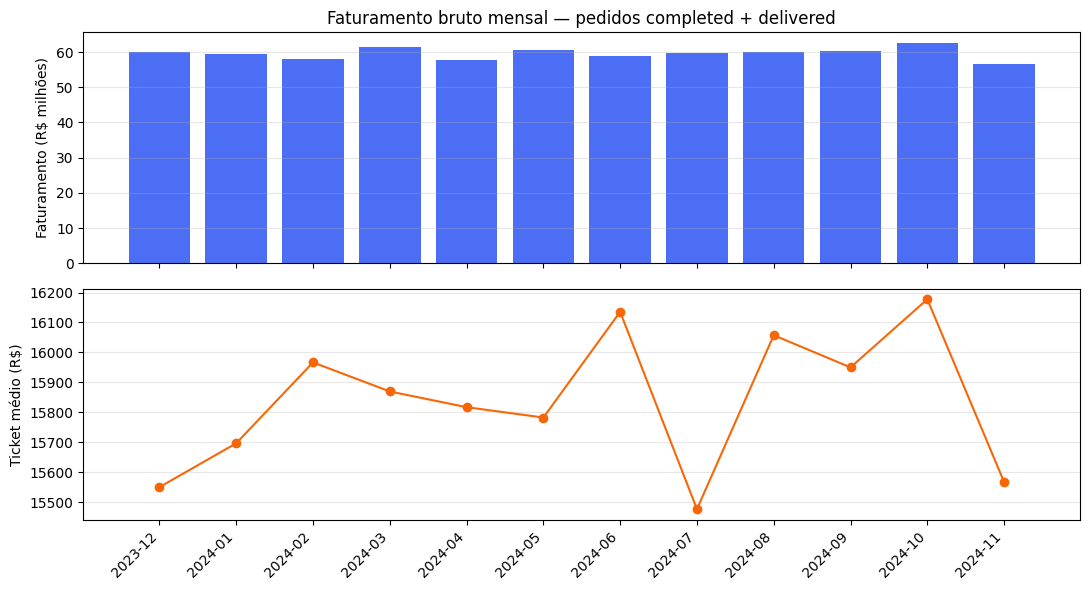

In [13]:
# Evolução do faturamento e do ticket médio nos 12 meses.
import matplotlib.pyplot as plt

grafico = resultado_desafio1.sort_values('mes')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

ax1.bar(grafico.mes, grafico.faturamento_bruto / 1e6, color='#4C6EF5')
ax1.set_ylabel('Faturamento (R$ milhões)')
ax1.set_title('Faturamento bruto mensal — pedidos completed + delivered')
ax1.grid(axis='y', alpha=.3)

ax2.plot(grafico.mes, grafico.ticket_medio, marker='o', color='#F76707')
ax2.set_ylabel('Ticket médio (R$)')
ax2.grid(axis='y', alpha=.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Uma ressalva antes de qualquer projeção em cima desses números: o faturamento é estável
demais. Doze meses entre R$ 56,7 mi e R$ 62,5 mi, sem sazonalidade e sem tendência, não
combina com um marketplace que se descreve em expansão. Para mim isso é indício de base
sintética (ou amostra achatada) — vale confirmar com o time antes de usar em forecast.

---
## Desafio 2 — Ranking de crescimento de GMV por seller

> *"A diretora comercial quer um ranking dos 10 sellers com maior crescimento de GMV
> entre o trimestre atual e o anterior, mas só quer ver sellers que tiveram pelo menos
> 50 pedidos em ambos os trimestres."*

A pergunta parece direta, mas tem um problema escondido: **qual é o "trimestre atual"?**
A leitura ingênua pegaria o trimestre da última data da base — 2024-Q4. Só que a base
termina em 29/11, então o Q4 tem dois meses em vez de três. Antes de decidir, medi o
tamanho do estrago.

In [14]:
# Quantos meses cada trimestre realmente tem?
pysqldf('''
    SELECT strftime('%Y', created_at) || '-Q' ||
               ((CAST(strftime('%m', created_at) AS INTEGER) + 2) / 3)  AS trimestre,
           COUNT(DISTINCT strftime('%Y-%m', created_at))                AS meses_com_dados,
           MIN(DATE(created_at))                                        AS primeiro_dia,
           MAX(DATE(created_at))                                        AS ultimo_dia,
           COUNT(*)                                                     AS pedidos,
           ROUND(SUM(total_value), 2)                                   AS gmv
    FROM orders
    WHERE status IN ('completed', 'delivered')
    GROUP BY 1
    ORDER BY 1
''')

,trimestre,meses_com_dados,primeiro_dia,ultimo_dia,pedidos,gmv
0,2023-Q3,2,2023-08-01,2023-09-30,7419,"116,426,239.53"
1,2023-Q4,3,2023-10-01,2023-12-31,11329,"177,959,510.58"
2,2024-Q1,3,2024-01-01,2024-03-31,11294,"178,925,543.05"
3,2024-Q2,3,2024-04-01,2024-06-30,11145,"177,307,402.68"
4,2024-Q3,3,2024-07-01,2024-09-30,11384,"180,146,409.27"
5,2024-Q4,2,2024-10-01,2024-11-29,7506,"119,203,677.76"


O primeiro e o último trimestre são parciais. Um trimestre cheio roda ~R$ 178 mi; o
2024-Q4 registra R$ 119 mi — não porque as vendas caíram, e sim porque falta um mês
inteiro de dados. E se eu comparasse o Q4 parcial contra o Q3 cheio mesmo assim?

In [15]:
# Simulação: 2024-Q4 (parcial) como "trimestre atual".
pysqldf('''
    WITH pedidos_por_trimestre AS (
        SELECT seller_id, total_value,
               DATE(strftime('%Y', created_at) || '-' ||
                    printf('%02d', ((CAST(strftime('%m', created_at) AS INTEGER) - 1) / 3) * 3 + 1) ||
                    '-01') AS inicio_trimestre
        FROM orders
        WHERE status IN ('completed', 'delivered')
    ),
    comparativo AS (
        SELECT seller_id,
               SUM(  CASE WHEN inicio_trimestre = '2024-07-01' THEN total_value END) AS gmv_q3,
               COUNT(CASE WHEN inicio_trimestre = '2024-07-01' THEN 1 END)           AS ped_q3,
               SUM(  CASE WHEN inicio_trimestre = '2024-10-01' THEN total_value END) AS gmv_q4,
               COUNT(CASE WHEN inicio_trimestre = '2024-10-01' THEN 1 END)           AS ped_q4
        FROM pedidos_por_trimestre
        WHERE inicio_trimestre IN ('2024-07-01', '2024-10-01')
        GROUP BY seller_id
    )
    SELECT COUNT(*)                                            AS sellers_no_corte_50,
           SUM(100.0 * (gmv_q4 - gmv_q3) / gmv_q3 > 0)         AS com_crescimento_positivo,
           ROUND(MAX(100.0 * (gmv_q4 - gmv_q3) / gmv_q3), 2)   AS melhor_resultado_pct,
           ROUND(MIN(100.0 * (gmv_q4 - gmv_q3) / gmv_q3), 2)   AS pior_resultado_pct
    FROM comparativo
    WHERE ped_q3 >= 50 AND ped_q4 >= 50
''')

,sellers_no_corte_50,com_crescimento_positivo,melhor_resultado_pct,pior_resultado_pct
0,43,0,-2.26,-50.09


O resultado fala por si: **zero** sellers com crescimento positivo, e o melhor
desempenho seria −2,26%. O "ranking dos que mais crescem" viraria "os que menos caíram",
e a diretora tomaria decisão sobre um artefato de calendário. De quebra, o corte de 50
pedidos despencaria de 118 para 43 sellers elegíveis — passaria a filtrar por falta de
dados, o contrário da intenção.

Então: **"trimestre atual" = último trimestre completo da base** (2024-Q3, comparado com
o Q2). A query descobre isso sozinha — um trimestre só vale se o seu último dia já
aconteceu nos dados — sem nenhuma data cravada no código.

Nas demais escolhas, mantive a mesma definição de GMV do Desafio 1 (`total_value` de
`completed` + `delivered`; incluir cancelado premiaria justamente quem gera pedido que
não se concretiza), contei os 50 pedidos sobre essa mesma população, e derivei o
trimestre pelo seu primeiro dia — o SQLite não tem função de trimestre, e ter uma data
real permite fazer `'-3 months'` direto.

In [16]:
desafio_2 = '''
WITH pedidos_deduplicados AS (
    -- mesma defesa dos demais desafios contra os 2 ids repetidos
    SELECT id, seller_id, status, created_at, total_value
    FROM (
        SELECT o.id,
               o.seller_id,
               o.status,
               o.created_at,
               o.total_value,
               ROW_NUMBER() OVER (
                   PARTITION BY o.id
                   ORDER BY o.created_at DESC
               ) AS versao
        FROM orders AS o
    )
    WHERE versao = 1
),

pedidos_faturados AS (
    -- GMV com a mesma régua do Desafio 1: completed + delivered.
    -- Guardo o 1º dia do trimestre: vira chave e permite aritmética com '-3 months'.
    SELECT p.seller_id,
           p.total_value,
           DATE(
               strftime('%Y', p.created_at) || '-' ||
               printf('%02d', ((CAST(strftime('%m', p.created_at) AS INTEGER) - 1) / 3) * 3 + 1) ||
               '-01'
           ) AS inicio_trimestre
    FROM pedidos_deduplicados AS p
    WHERE LOWER(TRIM(p.status)) IN ('completed', 'delivered')
      AND p.created_at  IS NOT NULL
      AND p.total_value IS NOT NULL
),

parametros AS (
    -- "trimestre atual" = último trimestre COMPLETO: o seu último dia precisa
    -- existir na base. Isso descarta o 2024-Q4, que só tem 2 dos 3 meses.
    SELECT MAX(inicio_trimestre)                    AS trimestre_atual,
           DATE(MAX(inicio_trimestre), '-3 months') AS trimestre_anterior
    FROM pedidos_faturados
    WHERE DATE(inicio_trimestre, '+3 months', '-1 day')
          <= (SELECT MAX(DATE(created_at)) FROM pedidos_deduplicados)
),

gmv_por_seller AS (
    -- pivô dos dois trimestres em uma única passada
    SELECT pf.seller_id,
           SUM(  CASE WHEN pf.inicio_trimestre = par.trimestre_anterior THEN pf.total_value END) AS gmv_anterior,
           COUNT(CASE WHEN pf.inicio_trimestre = par.trimestre_anterior THEN 1 END)              AS pedidos_anterior,
           SUM(  CASE WHEN pf.inicio_trimestre = par.trimestre_atual    THEN pf.total_value END) AS gmv_atual,
           COUNT(CASE WHEN pf.inicio_trimestre = par.trimestre_atual    THEN 1 END)              AS pedidos_atual
    FROM pedidos_faturados AS pf
    CROSS JOIN parametros AS par
    WHERE pf.inicio_trimestre IN (par.trimestre_anterior, par.trimestre_atual)
    GROUP BY pf.seller_id
)

SELECT s.name                    AS seller,
       s.state                   AS estado,
       ROUND(g.gmv_anterior, 2)  AS gmv_trimestre_anterior,
       ROUND(g.gmv_atual, 2)     AS gmv_trimestre_atual,
       -- o corte de 50 pedidos já garante GMV > 0, mas não custa proteger a divisão
       ROUND(100.0 * (g.gmv_atual - g.gmv_anterior) / NULLIF(g.gmv_anterior, 0), 2)
                                 AS crescimento_pct
FROM gmv_por_seller AS g
JOIN sellers AS s ON s.id = g.seller_id
-- corte pedido pela diretoria: fora sellers novos/inativos em qualquer dos trimestres
WHERE g.pedidos_anterior >= 50
  AND g.pedidos_atual    >= 50
ORDER BY crescimento_pct DESC
LIMIT 10
'''

resultado_desafio2 = pysqldf(desafio_2)
resultado_desafio2

,seller,estado,gmv_trimestre_anterior,gmv_trimestre_atual,crescimento_pct
0,Oliveira & Santos Distribuidora Distribuidora,PA,"707,665.01","1,198,419.33",69.35
1,Santos & Almeida Suprimentos Distribuidora,MG,"650,216.62","1,072,819.57",64.99
2,Nascimento & Ferreira Grupo Distribuidora,PB,"1,064,281.20","1,477,862.38",38.86
3,Lima & Souza Mercado Distribuidora,MG,"741,504.83","1,028,966.47",38.77
4,Souza & Almeida Suprimentos Distribuidora,RS,"907,742.32","1,245,697.34",37.23
5,Costa & Costa Atacado Distribuidora,SC,"2,419,835.47","3,199,599.63",32.22
6,Oliveira & Rodrigues Grupo Distribuidora,RN,"763,277.94","990,224.86",29.73
7,Silva & Santos Comércio Distribuidora,DF,"818,610.93","1,054,629.78",28.83
8,Ferreira & Oliveira Brasil Distribuidora,ES,"833,586.40","1,053,038.74",26.33
9,Santos & Silva Atacado Distribuidora,BA,"3,076,927.70","3,880,342.01",26.11


### O filtro de 50 pedidos está fazendo o que a diretora imagina?

In [17]:
# Quem cai no corte, e por quanto?
pysqldf('''
    WITH pedidos_por_trimestre AS (
        SELECT seller_id,
               COUNT(CASE WHEN created_at >= '2024-04-01' AND created_at < '2024-07-01' THEN 1 END) AS pedidos_q2,
               COUNT(CASE WHEN created_at >= '2024-07-01' AND created_at < '2024-10-01' THEN 1 END) AS pedidos_q3
        FROM orders
        WHERE status IN ('completed', 'delivered')
        GROUP BY seller_id
    )
    SELECT s.name   AS seller,
           s.state  AS estado,
           s.plan   AS plano,
           t.pedidos_q2,
           t.pedidos_q3
    FROM pedidos_por_trimestre AS t
    JOIN sellers AS s ON s.id = t.seller_id
    WHERE t.pedidos_q2 < 50 OR t.pedidos_q3 < 50
''')

,seller,estado,plano,pedidos_q2,pedidos_q3
0,Costa & Ferreira Atacado Distribuidora,PE,free,59,49
1,Nascimento & Nascimento Mercado Distribuidora,PR,premium,45,64


Quase nada, na verdade: exclui só 2 dos 120 sellers, ambos raspando na linha (49 e 45
pedidos) — não são novos nem inativos. Nesta base todos os sellers operam em todos os
trimestres, então o cenário que o filtro quer evitar nem existe aqui. O filtro continua
certo para dados reais (onde entra seller novo toda semana), mas achei importante
reportar que não é ele que está moldando o ranking.

Outra coisa que o percentual sozinho não conta: o crescimento veio de mais pedidos ou de
ticket maior? Para a diretora comercial isso muda a ação — expansão de demanda é uma
conversa, reajuste de preço ou concentração em poucos compradores grandes é outra.

In [18]:
# Decomposição do crescimento: volume (pedidos) × ticket médio.
pysqldf('''
    WITH comparativo AS (
        SELECT seller_id,
               SUM(  CASE WHEN created_at >= '2024-04-01' AND created_at < '2024-07-01' THEN total_value END) AS gmv_ant,
               COUNT(CASE WHEN created_at >= '2024-04-01' AND created_at < '2024-07-01' THEN 1 END)           AS ped_ant,
               SUM(  CASE WHEN created_at >= '2024-07-01' AND created_at < '2024-10-01' THEN total_value END) AS gmv_atu,
               COUNT(CASE WHEN created_at >= '2024-07-01' AND created_at < '2024-10-01' THEN 1 END)           AS ped_atu
        FROM orders
        WHERE status IN ('completed', 'delivered')
          AND created_at >= '2024-04-01' AND created_at < '2024-10-01'
        GROUP BY seller_id
    )
    SELECT s.name                                                            AS seller,
           c.ped_ant                                                         AS pedidos_ant,
           c.ped_atu                                                         AS pedidos_atual,
           ROUND(100.0 * (c.ped_atu - c.ped_ant) / c.ped_ant, 1)             AS var_pedidos_pct,
           ROUND(c.gmv_ant / c.ped_ant, 2)                                   AS ticket_ant,
           ROUND(c.gmv_atu / c.ped_atu, 2)                                   AS ticket_atual,
           ROUND(100.0 * ((c.gmv_atu / c.ped_atu) - (c.gmv_ant / c.ped_ant))
                       / (c.gmv_ant / c.ped_ant), 1)                         AS var_ticket_pct,
           ROUND(100.0 * (c.gmv_atu - c.gmv_ant) / c.gmv_ant, 1)             AS var_gmv_pct
    FROM comparativo AS c
    JOIN sellers AS s ON s.id = c.seller_id
    WHERE c.ped_ant >= 50 AND c.ped_atu >= 50
    ORDER BY var_gmv_pct DESC
    LIMIT 10
''')

,seller,pedidos_ant,pedidos_atual,var_pedidos_pct,ticket_ant,ticket_atual,var_ticket_pct,var_gmv_pct
0,Oliveira & Santos Distribuidora Distribuidora,68,87,27.90,"10,406.84","13,774.93",32.40,69.30
1,Santos & Almeida Suprimentos Distribuidora,52,85,63.50,"12,504.17","12,621.41",0.90,65.00
2,Nascimento & Ferreira Grupo Distribuidora,64,81,26.60,"16,629.39","18,245.21",9.70,38.90
3,Lima & Souza Mercado Distribuidora,50,65,30.00,"14,830.10","15,830.25",6.70,38.80
4,Souza & Almeida Suprimentos Distribuidora,71,91,28.20,"12,785.10","13,688.98",7.10,37.20
5,Costa & Costa Atacado Distribuidora,176,210,19.30,"13,749.07","15,236.19",10.80,32.20
6,Oliveira & Rodrigues Grupo Distribuidora,52,58,11.50,"14,678.42","17,072.84",16.30,29.70
7,Silva & Santos Comércio Distribuidora,58,59,1.70,"14,113.98","17,875.08",26.60,28.80
8,Ferreira & Oliveira Brasil Distribuidora,57,68,19.30,"14,624.32","15,485.86",5.90,26.30
9,Santos & Silva Atacado Distribuidora,212,218,2.80,"14,513.81","17,799.73",22.60,26.10


Contexto geral primeiro: dos 118 sellers elegíveis, 70 cresceram e 48 caíram, com média
de +2,3%. Ou seja, a plataforma está de lado — o top 10 é performance genuinamente acima
da média, não maré subindo para todo mundo.

Dentro do top 10, três padrões bem diferentes:

- **Crescimento por volume** — Santos & Almeida: +63,5% em pedidos com ticket parado
  (+0,9%). Conquista de demanda de fato; o caso mais saudável.
- **Crescimento por ticket** — Silva & Santos (+26,6% de ticket, +1,7% de pedidos) e
  Santos & Silva (+22,6% e +2,8%). O GMV subiu quase sem pedido novo. Pode ser mix, pode
  ser reajuste, pode ser meia dúzia de compradores grandes — se for concentração, é
  receita frágil. Vale investigar antes de comemorar.
- **Os dois eixos juntos** — Oliveira & Santos, o líder: +27,9% em pedidos e +32,4% no
  ticket ao mesmo tempo.

Uma ressalva estatística: 8 dos 10 têm base pequena (50–91 pedidos/trimestre), onde
poucos pedidos grandes mexem muito no percentual. Os únicos com volume relevante são
Costa & Costa (176→210) e Santos & Silva (212→218) — e, em reais absolutos, esses dois
adicionaram mais GMV do que os primeiros colocados. Eu acompanharia o ranking percentual
sempre ao lado do crescimento absoluto; ordenar só por percentual favorece o pequeno e
esconde onde o dinheiro se moveu.

---
## Desafio 3 — Pedidos com desconto abusivo

> *"O time de fraudes suspeita que alguns sellers estão aplicando descontos abusivos
> para inflar volume artificialmente. Encontre todos os pedidos onde o desconto total
> representa mais de 40% do valor bruto do pedido, listando o seller responsável e a
> data. Exclua pedidos cancelados."*

O enunciado pede a explicação do raciocínio, então vamos lá. Três decisões definem se o
resultado sai certo:

1. **O denominador.** "Valor bruto" é o preço de tabela antes do desconto:
   `SUM(qty * unit_price)`. A pegadinha é usar `orders.total_value` — que, como a
   auditoria mostrou, já vem líquido de desconto. Isso trocaria o denominador de
   `bruto` por `bruto − desconto` e inflaria todas as razões. Meço o tamanho desse erro
   logo abaixo.
2. **O nível de agregação.** Desconto abusivo é atributo do pedido, não do item — um
   item com 50% off dentro de um pedido grande pode ser promoção pontual. Por isso somo
   os itens por `order_id` antes de comparar.
3. **Comparar sem dividir.** `desconto > 0.40 * bruto` no lugar de
   `desconto / bruto > 0.40`: não tem como dividir por zero, e multiplicação sai mais
   barata numa varredura de 214 mil linhas.

Antes da query, olhei como o desconto se distribui — e a distribuição conta uma
história própria.

In [19]:
# Distribuição do desconto por item, em degraus de 5 pontos percentuais.
# Cuidado de SQLite: || tem precedência MAIOR que * e /, então "x * 5 || '%'"
# vira "x * (5 || '%')" — daí os parênteses extras.
pysqldf('''
    WITH percentual_por_item AS (
        SELECT 100.0 * discount / NULLIF(qty * unit_price, 0) AS pct
        FROM order_items
    )
    SELECT ((CAST(pct / 5 AS INTEGER)) * 5) || '% a ' ||
           ((CAST(pct / 5 AS INTEGER)) * 5 + 5) || '%'  AS faixa_desconto,
           COUNT(*)                                     AS itens
    FROM percentual_por_item
    GROUP BY CAST(pct / 5 AS INTEGER)
    ORDER BY MIN(pct)
''')

,faixa_desconto,itens
0,0% a 5%,69737
1,5% a 10%,69649
2,10% a 15%,70028
3,35% a 40%,1080
4,40% a 45%,1044
5,45% a 50%,1051
6,50% a 55%,1096
7,55% a 60%,1082
8,60% a 65%,1


Isso não é uma distribuição com cauda — são **duas populações separadas por um vazio**:

- de 0% a 15%, um regime uniforme com ~69,7 mil itens por faixa;
- entre 15% e 35%, **nenhum item**;
- de 35% a 60%, outro regime uniforme, com ~1,05 mil itens por faixa.

Não existe transição gradual. Não é "alguns sellers dão desconto um pouco maior": são
duas políticas de precificação distintas convivendo na plataforma, e a ausência total de
sobreposição sugere que o segundo regime segue uma regra própria, não negociação caso a
caso.

Agora o teste do denominador que mencionei:

In [20]:
# Quantos pedidos cada denominador sinalizaria?
pysqldf('''
    WITH itens_agregados AS (
        SELECT o.id,
               o.total_value,
               SUM(oi.qty * oi.unit_price)   AS valor_bruto,
               SUM(COALESCE(oi.discount, 0)) AS desconto_total
        FROM orders AS o
        JOIN order_items AS oi ON oi.order_id = o.id
        WHERE o.status <> 'cancelled'
        GROUP BY o.id
    )
    SELECT SUM(CASE WHEN desconto_total > 0.40 * valor_bruto THEN 1 ELSE 0 END) AS correto_bruto,
           SUM(CASE WHEN desconto_total > 0.40 * total_value THEN 1 ELSE 0 END) AS errado_liquido
    FROM itens_agregados
''')

,correto_bruto,errado_liquido
0,901,1655


Com o denominador errado sairiam **1.655** pedidos em vez de **901** — 84% a mais, ou
754 pedidos legítimos mandados para o time de fraudes investigar. Num processo que pode
terminar em suspensão de seller, esse erro custa caro dos dois lados: sobrecarrega a
investigação e desgasta a relação com seller inocente.

In [21]:
desafio_3 = '''
WITH pedidos_deduplicados AS (
    -- consistente com os desafios anteriores
    SELECT id, seller_id, status, created_at
    FROM (
        SELECT o.id,
               o.seller_id,
               o.status,
               o.created_at,
               ROW_NUMBER() OVER (
                   PARTITION BY o.id
                   ORDER BY o.created_at DESC
               ) AS versao
        FROM orders AS o
    )
    WHERE versao = 1
),

itens_agregados AS (
    -- valor bruto = preço de tabela ANTES do desconto (qty * unit_price);
    -- orders.total_value não serve aqui porque já vem líquido
    SELECT oi.order_id,
           SUM(oi.qty * oi.unit_price)   AS valor_bruto,
           SUM(COALESCE(oi.discount, 0)) AS desconto_total,
           COUNT(*)                      AS qtd_itens
    FROM order_items AS oi
    GROUP BY oi.order_id
)

SELECT p.id                                          AS pedido_id,
       s.name                                        AS seller,
       s.state                                       AS estado,
       DATE(p.created_at)                            AS data_pedido,
       p.status                                      AS status_pedido,
       ia.qtd_itens,
       ROUND(ia.valor_bruto, 2)                      AS valor_bruto,
       ROUND(ia.desconto_total, 2)                   AS desconto_total,
       ROUND(ia.valor_bruto - ia.desconto_total, 2)  AS valor_liquido,
       ROUND(100.0 * ia.desconto_total / ia.valor_bruto, 2) AS desconto_pct
FROM pedidos_deduplicados AS p
JOIN itens_agregados AS ia ON ia.order_id = p.id
JOIN sellers         AS s  ON s.id = p.seller_id
WHERE LOWER(TRIM(p.status)) <> 'cancelled'
  AND ia.valor_bruto > 0
  -- "mais de 40%": comparação por multiplicação, sem risco de divisão por zero
  AND ia.desconto_total > 0.40 * ia.valor_bruto
ORDER BY desconto_pct DESC
'''

resultado_desafio3 = pysqldf(desafio_3)

print(f'Pedidos sinalizados: {len(resultado_desafio3):,}')
print(f'Sellers envolvidos : {resultado_desafio3.seller.nunique()} de 120')
print(f'Desconto concedido : R$ {resultado_desafio3.desconto_total.sum():,.2f} '
      f'sobre R$ {resultado_desafio3.valor_bruto.sum():,.2f} de valor bruto')
resultado_desafio3.head(15)

Pedidos sinalizados: 901
Sellers envolvidos : 8 de 120
Desconto concedido : R$ 6,072,636.36 sobre R$ 12,895,535.79 de valor bruto


,pedido_id,seller,estado,data_pedido,status_pedido,qtd_itens,valor_bruto,desconto_total,valor_liquido,desconto_pct
0,72401,Costa & Oliveira Atacado Distribuidora,BA,2024-01-21,delivered,1,930.30,558.02,372.28,59.98
1,42513,Costa & Costa Atacado Distribuidora,SC,2024-03-27,completed,1,"4,082.60","2,447.96","1,634.64",59.96
2,36119,Costa & Costa Atacado Distribuidora,SC,2024-11-14,delivered,1,"21,030.24","12,598.00","8,432.24",59.90
3,53223,Costa & Costa Atacado Distribuidora,SC,2024-05-06,delivered,1,"7,970.40","4,773.99","3,196.41",59.90
4,71165,Santos & Almeida Suprimentos Distribuidora,MG,2024-11-09,completed,1,"13,385.60","8,017.88","5,367.72",59.90
5,8021,Costa & Costa Atacado Distribuidora,SC,2024-05-16,processing,1,"8,302.80","4,972.58","3,330.22",59.89
6,840,Souza & Almeida Suprimentos Distribuidora,RS,2024-04-29,completed,1,"15,754.95","9,423.26","6,331.69",59.81
7,44426,Costa & Costa Atacado Distribuidora,SC,2024-04-08,delivered,1,"4,336.66","2,586.99","1,749.67",59.65
8,53817,Costa & Costa Atacado Distribuidora,SC,2024-01-02,refunded,1,"1,404.78",837.12,567.66,59.59
9,8298,Costa & Costa Atacado Distribuidora,SC,2023-11-07,delivered,1,"1,826.89","1,088.31",738.58,59.57


901 pedidos — e **todos vindos de apenas 8 dos 120 sellers**. Se desconto alto fosse
prática comercial difusa, estaria espalhado pela base. Vamos ver a frequência com que
cada um dos 8 faz isso:

In [22]:
pysqldf('''
    WITH itens_agregados AS (
        SELECT order_id,
               SUM(qty * unit_price)      AS valor_bruto,
               SUM(COALESCE(discount, 0)) AS desconto_total
        FROM order_items
        GROUP BY order_id
    )
    SELECT s.name                                                                     AS seller,
           s.state                                                                    AS estado,
           s.plan                                                                     AS plano,
           COUNT(*)                                                                   AS pedidos_totais,
           SUM(CASE WHEN ia.desconto_total > 0.40 * ia.valor_bruto THEN 1 ELSE 0 END) AS pedidos_sinalizados,
           ROUND(100.0 * SUM(CASE WHEN ia.desconto_total > 0.40 * ia.valor_bruto THEN 1 ELSE 0 END)
                       / COUNT(*), 2)                                                 AS taxa_pct,
           ROUND(100.0 * SUM(ia.desconto_total) / SUM(ia.valor_bruto), 2)             AS desconto_medio_ponderado
    FROM orders AS o
    JOIN itens_agregados AS ia ON ia.order_id = o.id
    JOIN sellers         AS s  ON s.id = o.seller_id
    WHERE o.status <> 'cancelled'
    GROUP BY s.id
    HAVING pedidos_sinalizados > 0
    ORDER BY taxa_pct DESC
''')

,seller,estado,plano,pedidos_totais,pedidos_sinalizados,taxa_pct,desconto_medio_ponderado
0,Oliveira & Santos Distribuidora Distribuidora,PA,basic,454,104,22.91,24.36
1,Santos & Almeida Suprimentos Distribuidora,MG,free,468,104,22.22,24.64
2,Souza & Almeida Suprimentos Distribuidora,RS,premium,469,96,20.47,23.56
3,Santos & Rodrigues Distribuidora Distribuidora,AM,basic,426,87,20.42,23.53
4,Souza & Ferreira Alimentos Distribuidora,MG,premium,433,87,20.09,23.66
5,Costa & Costa Atacado Distribuidora,SC,free,1276,254,19.91,23.37
6,Oliveira & Costa Comércio Distribuidora,GO,basic,437,86,19.68,23.87
7,Costa & Oliveira Atacado Distribuidora,BA,basic,449,83,18.49,23.08


O padrão é sistemático: cada um dos 8 sinaliza entre 18,5% e 22,9% dos próprios pedidos,
com desconto médio ponderado em torno de 23,7% — contra 7,5% dos outros 112 sellers.
Três vezes a taxa da plataforma, de forma quase idêntica entre oito empresas diferentes,
não é comportamento comercial espontâneo.

Mas a suspeita do time de fraudes tinha duas partes: descontos abusivos (ok, confirmado)
**para inflar volume artificialmente**. Essa segunda parte dá para testar cruzando com o
ranking de crescimento do Desafio 2:

In [23]:
pysqldf('''
    WITH itens_agregados AS (
        SELECT order_id,
               SUM(qty * unit_price)      AS valor_bruto,
               SUM(COALESCE(discount, 0)) AS desconto_total
        FROM order_items
        GROUP BY order_id
    ),
    sellers_sinalizados AS (
        SELECT DISTINCT o.seller_id
        FROM orders AS o
        JOIN itens_agregados AS ia ON ia.order_id = o.id
        WHERE o.status <> 'cancelled'
          AND ia.desconto_total > 0.40 * ia.valor_bruto
    ),
    crescimento AS (
        SELECT seller_id,
               SUM(  CASE WHEN created_at >= '2024-04-01' AND created_at < '2024-07-01' THEN total_value END) AS gmv_ant,
               COUNT(CASE WHEN created_at >= '2024-04-01' AND created_at < '2024-07-01' THEN 1 END)           AS ped_ant,
               SUM(  CASE WHEN created_at >= '2024-07-01' AND created_at < '2024-10-01' THEN total_value END) AS gmv_atu,
               COUNT(CASE WHEN created_at >= '2024-07-01' AND created_at < '2024-10-01' THEN 1 END)           AS ped_atu
        FROM orders
        WHERE status IN ('completed', 'delivered')
        GROUP BY seller_id
    ),
    ranking AS (
        SELECT c.seller_id,
               100.0 * (c.gmv_atu - c.gmv_ant) / c.gmv_ant AS crescimento_pct,
               ROW_NUMBER() OVER (ORDER BY 100.0 * (c.gmv_atu - c.gmv_ant) / c.gmv_ant DESC) AS posicao,
               CASE WHEN ss.seller_id IS NOT NULL THEN 'SIM' ELSE '-' END AS desconto_abusivo
        FROM crescimento AS c
        LEFT JOIN sellers_sinalizados AS ss ON ss.seller_id = c.seller_id
        WHERE c.ped_ant >= 50 AND c.ped_atu >= 50
    )
    SELECT r.posicao,
           s.name                      AS seller,
           s.state                     AS uf,
           ROUND(r.crescimento_pct, 2) AS crescimento_pct,
           r.desconto_abusivo
    FROM ranking AS r
    JOIN sellers AS s ON s.id = r.seller_id
    WHERE r.posicao <= 10
    ORDER BY r.posicao
''')

,posicao,seller,uf,crescimento_pct,desconto_abusivo
0,1,Oliveira & Santos Distribuidora Distribuidora,PA,69.35,SIM
1,2,Santos & Almeida Suprimentos Distribuidora,MG,64.99,SIM
2,3,Nascimento & Ferreira Grupo Distribuidora,PB,38.86,-
3,4,Lima & Souza Mercado Distribuidora,MG,38.77,-
4,5,Souza & Almeida Suprimentos Distribuidora,RS,37.23,SIM
5,6,Costa & Costa Atacado Distribuidora,SC,32.22,SIM
6,7,Oliveira & Rodrigues Grupo Distribuidora,RN,29.73,-
7,8,Silva & Santos Comércio Distribuidora,DF,28.83,-
8,9,Ferreira & Oliveira Brasil Distribuidora,ES,26.33,-
9,10,Santos & Silva Atacado Distribuidora,BA,26.11,-


Aí está: os 8 sellers sinalizados são 6,7% da base, mas ocupam **4 das 10 posições do
ranking de crescimento — incluindo o 1º e o 2º lugar**. Umas 6 vezes a presença esperada
se crescimento e desconto fossem independentes. O ranking que premiaria performance
está, no topo, medindo desconto agressivo convertido em GMV. A hipótese do time de
fraudes se sustenta.

Quatro ressalvas que eu levaria junto com o resultado:

1. **O limiar de 40% corta no lugar errado.** A distribuição mostrou que o regime
   anômalo começa em 35%. Um corte em 30% — dentro do vazio entre as duas populações —
   capturaria 1.564 pedidos em vez de 901; os 663 entre 30% e 40% têm o mesmo
   comportamento dos sinalizados e escapam da régua atual. Eu proporia mover o limiar
   para 30%.
2. **"Excluir cancelados" merece segunda olhada.** Segui o enunciado (`status <>
   'cancelled'`), o que descarta 91 pedidos. Para investigação de fraude, porém, pedido
   cancelado com 55% de desconto é evidência, não ruído — eu os manteria numa visão
   separada.
3. **Padrão anômalo ≠ fraude provada.** Os dados mostram concentração e sistematicidade,
   não intenção. Os 8 estão em planos e estados variados — não parece haver um programa
   comercial que os una, mas essa confirmação é do time comercial, não minha.
4. **A análise que fecharia o caso — margem — eu tentei e não dá.** A ideia era checar se
   o preço com desconto cai abaixo de `products.unit_cost` (vender abaixo do custo seria
   o indício forte). O teste abaixo mostra por que abandonei.

In [24]:
# Preço praticado vs custo cadastrado: faz sentido econômico?
pysqldf('''
    SELECT ROUND(MIN(100.0 * (oi.unit_price - p.unit_cost) / p.unit_cost), 1) AS markup_minimo_pct,
           ROUND(AVG(100.0 * (oi.unit_price - p.unit_cost) / p.unit_cost), 1) AS markup_medio_pct,
           ROUND(MAX(100.0 * (oi.unit_price - p.unit_cost) / p.unit_cost), 1) AS markup_maximo_pct,
           SUM(oi.unit_price < p.unit_cost)                                   AS itens_vendidos_abaixo_do_custo,
           ROUND(100.0 * SUM(oi.unit_price < p.unit_cost) / COUNT(*), 2)      AS pct_abaixo_do_custo
    FROM order_items AS oi
    JOIN products AS p ON p.id = oi.product_id
''')

,markup_minimo_pct,markup_medio_pct,markup_maximo_pct,itens_vendidos_abaixo_do_custo,pct_abaixo_do_custo
0,-97.50,468.60,"23,935.10",41201,19.18


Markup de −97,5% a +23.935%, e 19,2% dos itens já saem abaixo do custo **sem nenhum
desconto anômalo**. Preço e custo não guardam relação nesta base — `unit_cost` parece
ter sido gerado à parte. Qualquer conclusão sobre margem seria artefato do dado, então
deixei a análise registrada como bloqueada até alguém confirmar se `unit_cost` reflete
custo real. (Se refletir, aliás, a plataforma tem um problema de precificação bem maior
que o dos descontos.)

---
## Desafio 4 — Produtos que nunca são o item de maior valor

> *"Existe um produto com comportamento estranho: ele tem um volume de vendas alto, mas
> nunca aparece como item mais vendido dentro de nenhum pedido (nunca é o item de maior
> valor num pedido). Encontre todos os produtos que se encaixam nessa descrição: total
> de unidades vendidas > 1.000, mas que em nenhum pedido foram o item de maior valor
> unitário."*
>
> *Dica: window functions podem ser suas aliadas aqui e avalie os resultados e
> viabilidade da análise e faça os questionamentos necessários.*

Primeiro questionamento, antes de qualquer SQL: o enunciado descreve o critério de três
jeitos que não são equivalentes. "Item mais **vendido** do pedido" aponta para `qty`;
"item de maior **valor**" aponta para `qty * unit_price`; "maior **valor unitário**"
aponta para `unit_price`. São três perguntas de negócio diferentes — ser o produto mais
caro do carrinho não é o mesmo que ser o item que mais pesou na compra.

Fui com `unit_price`, que é o que está na especificação formal da tarefa, mas rodo as
três versões no final — essa escolha deveria ser de quem fez a pergunta, não de quem
escreve a query.

Segundo ponto: empate. Se dois itens do mesmo pedido têm exatamente o mesmo preço,
`ROW_NUMBER()` rebaixaria um deles arbitrariamente — e um produto poderia constar como
"nunca foi o mais caro" por sorteio interno do banco. `RANK()` dá posição 1 aos dois,
que é a semântica certa. Verifiquei: existem 3 pedidos nessa situação.

In [25]:
# Empates reais no topo do pedido (mesmo unit_price máximo).
pysqldf('''
    WITH itens_ranqueados AS (
        SELECT order_id,
               RANK() OVER (PARTITION BY order_id ORDER BY unit_price DESC) AS posicao
        FROM order_items
    )
    SELECT COUNT(*)                             AS linhas_em_primeiro,
           COUNT(DISTINCT order_id)             AS pedidos,
           COUNT(*) - COUNT(DISTINCT order_id)  AS empates
    FROM itens_ranqueados
    WHERE posicao = 1
''')

,linhas_em_primeiro,pedidos,empates
0,80003,80000,3


In [26]:
desafio_4 = '''
WITH itens_ranqueados AS (
    -- window function posicionando cada item dentro do próprio pedido, por preço
    -- unitário; RANK (não ROW_NUMBER) para empates dividirem o 1º lugar
    SELECT oi.product_id,
           oi.qty,
           RANK() OVER (
               PARTITION BY oi.order_id
               ORDER BY oi.unit_price DESC
           ) AS posicao_no_pedido
    FROM order_items AS oi
),

metricas_por_produto AS (
    SELECT product_id,
           SUM(qty)                                               AS unidades_vendidas,
           COUNT(*)                                               AS aparicoes_em_pedidos,
           SUM(CASE WHEN posicao_no_pedido = 1 THEN 1 ELSE 0 END) AS vezes_item_mais_caro
    FROM itens_ranqueados
    GROUP BY product_id
)

SELECT p.id       AS produto_id,
       p.name     AS produto,
       p.category AS categoria,
       m.unidades_vendidas,
       m.aparicoes_em_pedidos,
       m.vezes_item_mais_caro
FROM metricas_por_produto AS m
JOIN products AS p ON p.id = m.product_id
WHERE m.unidades_vendidas   > 1000   -- volume de vendas alto
  AND m.vezes_item_mais_caro = 0     -- nunca foi o item de maior valor unitário
ORDER BY m.unidades_vendidas DESC
'''

resultado_desafio4 = pysqldf(desafio_4)

print(f'Produtos encontrados: {len(resultado_desafio4)}')
resultado_desafio4

Produtos encontrados: 0


,produto_id,produto,categoria,unidades_vendidas,aparicoes_em_pedidos,vezes_item_mais_caro


### Zero produtos. Bug ou resposta?

Resultado vazio nunca deve ser entregue sem explicação — pode significar "nada se
encaixa" ou "a query está errada". Fui atrás da causa, e a conclusão é que **zero é o
resultado estruturalmente correto para esta base**. A evidência, em quatro passos:

In [27]:
# Passo 1: o corte de 1.000 unidades filtra alguém?
pysqldf('''
    WITH unidades AS (
        SELECT product_id, SUM(qty) AS unidades_vendidas
        FROM order_items
        GROUP BY product_id
    )
    SELECT COUNT(*)                          AS total_produtos,
           SUM(unidades_vendidas > 1000)     AS acima_de_1000_unidades,
           MIN(unidades_vendidas)            AS minimo_vendido,
           ROUND(AVG(unidades_vendidas), 0)  AS media_vendida,
           MAX(unidades_vendidas)            AS maximo_vendido
    FROM unidades
''')

,total_produtos,acima_de_1000_unidades,minimo_vendido,media_vendida,maximo_vendido
0,800,800,5322,"6,851.00",8793


In [28]:
# Passo 2: quantos pedidos têm um item só (onde ser "o mais caro" é automático)?
pysqldf('''
    WITH itens_por_pedido AS (
        SELECT order_id, COUNT(*) AS qtd_itens
        FROM order_items
        GROUP BY order_id
    )
    SELECT qtd_itens                                                            AS itens_no_pedido,
           COUNT(*)                                                             AS pedidos,
           ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM itens_por_pedido), 2) AS pct
    FROM itens_por_pedido
    GROUP BY qtd_itens
    ORDER BY qtd_itens
''')

,itens_no_pedido,pedidos,pct
0,1,15915,19.89
1,2,23784,29.73
2,3,20378,25.47
3,4,11873,14.84
4,5,5641,7.05
5,6,2409,3.01


O corte de 1.000 não exclui ninguém: **todos os 800 produtos passam**, e o menos vendido
tem 5.322 unidades — cinco vezes o limiar. E um em cada cinco pedidos (19,9%, quase 16
mil) tem um único item, situação em que o item é o mais caro por definição. Só isso já
faz cada produto "vencer" umas 20 vezes de graça.

Mas a causa de fundo é outra, e aparece quando se olha o preço:

In [29]:
# Passo 3: o preço é do produto ou da venda?
pysqldf('''
    WITH precos_por_produto AS (
        SELECT product_id,
               COUNT(*)                   AS linhas,
               COUNT(DISTINCT unit_price) AS precos_distintos,
               MIN(unit_price)            AS preco_minimo,
               MAX(unit_price)            AS preco_maximo
        FROM order_items
        GROUP BY product_id
    )
    SELECT COUNT(*)                        AS produtos,
           ROUND(AVG(linhas), 1)           AS linhas_por_produto,
           ROUND(AVG(precos_distintos), 1) AS precos_distintos_por_produto,
           SUM(precos_distintos = 1)       AS produtos_com_preco_fixo,
           ROUND(AVG(preco_minimo), 2)     AS media_do_preco_minimo,
           ROUND(AVG(preco_maximo), 2)     AS media_do_preco_maximo
    FROM precos_por_produto
''')

,produtos,linhas_por_produto,precos_distintos_por_produto,produtos_com_preco_fixo,media_do_preco_minimo,media_do_preco_maximo
0,800,268.50,267.70,0,6.94,498.15


**O preço não é atributo do produto nesta base.** Cada produto aparece com 267,7 preços
distintos em 268 linhas — um preço novo a cada venda, nenhum produto com preço fixo, e
todos varrendo a mesma faixa (de ~R$ 5 a ~R$ 500, a amplitude da base inteira).

Isso desmonta a premissa da pergunta. "Produto que nunca é o mais caro do pedido" supõe
que exista produto barato e produto caro. Aqui não existe produto barato — existe *venda*
barata. Sem identidade de preço, nenhum produto consegue ficar sistematicamente fora do
topo.

Dá para fechar a questão com estatística básica:

In [30]:
# Passo 4: a variação entre produtos é maior que o esperado por puro acaso?
import math

taxas = pysqldf('''
    WITH itens_ranqueados AS (
        SELECT product_id,
               RANK() OVER (PARTITION BY order_id ORDER BY unit_price DESC) AS posicao
        FROM order_items
    )
    SELECT product_id,
           COUNT(*)                                     AS aparicoes,
           SUM(CASE WHEN posicao = 1 THEN 1 ELSE 0 END) AS vezes_topo,
           100.0 * SUM(CASE WHEN posicao = 1 THEN 1 ELSE 0 END) / COUNT(*) AS taxa_topo
    FROM itens_ranqueados
    GROUP BY product_id
''')

p_global   = taxas.vezes_topo.sum() / taxas.aparicoes.sum()
aparicoes  = taxas.aparicoes.mean()
desvio_obs = taxas.taxa_topo.std()
desvio_esp = 100 * math.sqrt(p_global * (1 - p_global) / aparicoes)

print(f'Produtos analisados            : {len(taxas)}')
print(f'Aparições médias por produto   : {aparicoes:.1f}')
print(f'Taxa de "ser o mais caro"      : mín {taxas.taxa_topo.min():.2f}%  |  '
      f'média {taxas.taxa_topo.mean():.2f}%  |  máx {taxas.taxa_topo.max():.2f}%')
print()
print(f'Desvio-padrão observado                    : {desvio_obs:.2f} pp')
print(f'Desvio-padrão esperado se fosse puro acaso : {desvio_esp:.2f} pp')
print()
print(f'P(um produto nunca ser o mais caro em {aparicoes:.0f} aparições) = '
      f'(1 - {p_global:.4f})^{aparicoes:.0f} ≈ 10^{aparicoes * math.log10(1 - p_global):.0f}')

Produtos analisados            : 800
Aparições médias por produto   : 268.5
Taxa de "ser o mais caro"      : mín 26.85%  |  média 37.25%  |  máx 46.89%

Desvio-padrão observado                    : 3.01 pp
Desvio-padrão esperado se fosse puro acaso : 2.95 pp

P(um produto nunca ser o mais caro em 268 aparições) = (1 - 0.3725)^268 ≈ 10^-54


O desvio-padrão observado entre produtos (3,01 pp) é praticamente igual ao que se
esperaria de um sorteio independente por aparição (2,95 pp): toda a diferença entre os
800 produtos é ruído amostral. O produto menos "protagonista" ainda lidera 26,85% das
vezes — longe de nunca. E a chance de um produto qualquer nunca liderar em 268 aparições
é da ordem de 10⁻⁵⁴. O produto do enunciado não é raro nesta base: é impossível.

Por fim, aquela ambiguidade das três definições — será que alguma delas mudaria o
resultado?

In [31]:
# As três leituras do enunciado, numa passada só.
pysqldf('''
    WITH itens_ranqueados AS (
        SELECT oi.product_id,
               oi.qty,
               RANK() OVER (PARTITION BY oi.order_id ORDER BY oi.unit_price DESC)          AS rk_preco_unitario,
               RANK() OVER (PARTITION BY oi.order_id ORDER BY oi.qty * oi.unit_price DESC) AS rk_valor_linha,
               RANK() OVER (PARTITION BY oi.order_id ORDER BY oi.qty DESC)                 AS rk_quantidade
        FROM order_items AS oi
    ),
    resumo AS (
        SELECT product_id,
               SUM(qty)               AS unidades,
               MIN(rk_preco_unitario) AS melhor_preco_unitario,
               MIN(rk_valor_linha)    AS melhor_valor_linha,
               MIN(rk_quantidade)     AS melhor_quantidade
        FROM itens_ranqueados
        GROUP BY product_id
    )
    SELECT COUNT(*)                       AS produtos_com_mais_de_1000_un,
           SUM(melhor_preco_unitario > 1) AS nunca_topo_por_preco_unitario,
           SUM(melhor_valor_linha    > 1) AS nunca_topo_por_valor_da_linha,
           SUM(melhor_quantidade     > 1) AS nunca_topo_por_quantidade
    FROM resumo
    WHERE unidades > 1000
''')

,produtos_com_mais_de_1000_un,nunca_topo_por_preco_unitario,nunca_topo_por_valor_da_linha,nunca_topo_por_quantidade
0,800,0,0,0


Zero nas três leituras (e também zero se eu descartar os pedidos de item único — testei
à parte). A ambiguidade do enunciado não explica o vazio; a estrutura dos dados explica.

### O que eu levaria de volta ao time

A pergunta de negócio é boa. Produto de giro alto que nunca protagoniza a compra é o
clássico item complementar — vai de carona no carrinho, não motiva o pedido — e saber
quais são muda decisão de preço, campanha e sortimento. O problema não é a pergunta, é
que esta base não consegue respondê-la. Meus questionamentos:

1. Qual das três definições de "maior" interessa de fato? Cada uma responde outra coisa.
2. Por que `unit_price` muda a cada linha? Se for ruído de geração da base, precisamos
   da tabela de preços real. Se for comportamento genuíno (preço 100% negociado por
   pedido), então "produto caro" não existe neste negócio — e não é só esta análise que
   fica inviável.
3. De onde saiu o limiar de 1.000 unidades? Ele não corta nenhum produto. Um corte
   adaptativo (percentil 90 de unidades, por exemplo) isolaria de verdade o topo do
   catálogo.
4. Eu trocaria o critério binário ("nunca foi o maior") por um contínuo — participação
   média do produto no valor do pedido, ou taxa de vezes em que lidera. O binário é
   frágil: uma única aparição num pedido de item único zera tudo. Numa base com preço
   de verdade, esse índice entregaria a resposta que o enunciado procura.

---
## Síntese

Os quatro desafios acabam contando uma história só. O faturamento circulava 32,8%
inflado porque cada área usava uma definição própria de "pedido válido" (Desafio 1). A
janela de comparação, se ancorada no trimestre parcial, transformaria calendário em
queda generalizada e inverteria o ranking apresentado à diretoria (Desafio 2). Os 8
sellers com política de desconto fora da curva ocupam 4 das 10 posições desse mesmo
ranking — ou seja, parte do "crescimento" que seria premiado é desconto convertido em
GMV (Desafio 3). E nem toda pergunta bem formulada é respondível com os dados que se tem
(Desafio 4).

O fio comum: **a régua importa tanto quanto o cálculo**. Status considerado, janela
temporal, denominador, critério de "maior" — em todos os casos, a decisão de modelagem
mudou o resultado mais do que qualquer detalhe de SQL. É exatamente assim que nascem
"números diferentes dependendo de quem puxa o relatório". A correção duradoura é
materializar essas definições em camada modelada (uma view canônica de pedidos
faturáveis, uma definição única de GMV), não distribuir queries melhores.

Fica também o registro do que sugere base sintética — faturamento sem sazonalidade,
descontos em dois regimes uniformes separados por um vazio, preço independente do custo
e do produto. Nada disso invalida os exercícios, mas eu confirmaria com o time antes de
levar qualquer número daqui para decisão real.